# MIMIC-IV AKI Dataset — Comprehensive Statistical Description

**Purpose:** Provide complete descriptive statistics for the MIMIC-IV AKI cohort, following clinical AI paper checklist requirements.

**Sections:**
1. **Dataset-level Statistics** — Baseline characteristics / Table 1 (Checklist Item 7)
2. **Feature-level Statistics** — Descriptive stats per variable (Checklist Item 9)
3. **Data Quality** — Missing rates, class imbalance (Checklist Items 6, 11, 13)

**Data source:** MIMIC-IV (Medical Information Mart for Intensive Care)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 8),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'savefig.bbox': 'tight'
})
sns.set_style('whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)

print("All imports loaded successfully.")

All imports loaded successfully.


In [2]:
df = pd.read_csv('AKI_patients_with_features.csv', index_col=0)
print(f'Dataset shape: {df.shape}')
print(f'Number of patients: {len(df)}')
print(f'Number of features: {len(df.columns)}')
print()
print('Columns and data types:')
for i, (col, dtype) in enumerate(df.dtypes.items(), 1):
    print(f'  {i:2d}. {col:<45s} {str(dtype)}')
print()
print('First 3 rows:')
display(df.head(3))

Dataset shape: (2316, 69)
Number of patients: 2316
Number of features: 69

Columns and data types:
   1. subject_id                                    int64
   2. hadm_id                                       int64
   3. stay_id                                       int64
   4. aki_label                                     int64
   5. gender                                        object
   6. admission_age                                 int64
   7. race                                          object
   8. weight                                        float64
   9. height                                        float64
  10. first_careunit                                object
  11. first_hosp_stay                               bool
  12. heart_rate_max                                float64
  13. sys_bp_min                                    float64
  14. mean_bp_min                                   float64
  15. dias_bp_min                                   float64
  16. resp_rate_m

,subject_id,hadm_id,stay_id,aki_label,gender,admission_age,race,weight,height,first_careunit,first_hosp_stay,heart_rate_max,sys_bp_min,mean_bp_min,dias_bp_min,resp_rate_max,temperature_max,glucose_vitalsign_max,creatinine_min,bun_max,bicarbonate_min,potassium_chemistry_max,aniongap_max,albumin_median,glucose_chemistry_max,urineoutput_12h_sum,hemoglobin_min,hematocrit_min,wbc_max,platelet_median,rdw_median,nlr_max,bands_max,troponin_t_max,ck_mb_max,ntprobnp_max,inr_median,pt_median,ptt_median,fibrinogen_median,ck_cpk_max,ld_ldh_max,alt_max,ast_max,bilirubin_total_max,alp_median,amylase_median,gcs_unable_max,is_afib,is_paced,is_high_grade_block,invasive_vent_flag,non_invasive_vent_flag,peep_max,fio2_max,plateau_pressure_max,tidal_volume_observed_max,vaso_flag,norepinephrine_equivalent_dose_max,infection_suspected_flag,blood_culture_flag,use_aspirin,has_acei,use_vancomycin_iv,cnt_systemic_antibiotics,has_mcs_device,has_pa_catheter,is_femoral_access,cnt_invasive_lines
0,10002155,23822395,33685454,1,F,81,WHITE,53.0,NaN,Coronary Care Unit (CCU),True,83.0,98.0,66.0,46.0,20.0,36.61,95.0,0.9,19.0,25.0,4.5,13.0,NaN,95.0,1390.0,12.5,37.9,5.5,185.0,15.2,NaN,NaN,3.99,107.0,NaN,NaN,NaN,NaN,NaN,589.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.00,1.0,0.0,1,1,0,0,0,0,1,2
1,10002495,24982426,36753294,1,M,81,UNKNOWN,64.1,170.0,Coronary Care Unit (CCU),True,115.0,72.0,47.0,40.0,26.0,37.06,331.0,1.4,35.0,14.0,4.1,23.0,NaN,331.0,2955.0,14.0,40.6,36.8,180.5,12.4,30.445455,10.0,1.75,96.0,NaN,1.3,14.5,49.60,NaN,NaN,310.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,1.0,0.04,1.0,0.0,1,0,0,3,0,0,0,0
2,10002667,23197839,31573075,1,F,58,WHITE,87.7,165.0,Cardiac Vascular Intensive Care Unit (CVICU),True,93.0,100.0,77.0,43.0,52.0,37.61,93.0,0.7,10.0,21.0,4.0,13.0,3.6,93.0,775.0,10.3,32.0,8.7,199.0,13.8,NaN,NaN,NaN,NaN,NaN,1.0,10.9,69.25,NaN,NaN,NaN,40.0,32.0,0.5,97.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.00,0.0,0.0,0,0,0,0,1,0,1,2


---
## 1. Dataset-level Statistics — Baseline Characteristics (Table 1)

> **Checklist Item 7:** Describe population demographics: age, sex, race/ethnicity, comorbidities, etc.
>
> Stratified by AKI status with p-values (Mann-Whitney U for continuous, Chi-square/Fisher for categorical).

In [3]:
# Define variable categories
continuous_vars = [
    # Demographics
    'admission_age', 'weight', 'height',
    # Vital signs
    'heart_rate_max', 'sys_bp_min', 'mean_bp_min', 'dias_bp_min',
    'resp_rate_max', 'temperature_max', 'glucose_vitalsign_max',
    # Renal / Electrolytes
    'creatinine_min', 'bun_max', 'bicarbonate_min', 'potassium_chemistry_max',
    'aniongap_max', 'albumin_median', 'glucose_chemistry_max',
    # Urine output
    'urineoutput_12h_sum',
    # Hematology
    'hemoglobin_min', 'hematocrit_min', 'wbc_max', 'platelet_median',
    'rdw_median', 'nlr_max', 'bands_max',
    # Cardiac biomarkers
    'troponin_t_max', 'ck_mb_max', 'ntprobnp_max',
    # Coagulation
    'inr_median', 'pt_median', 'ptt_median', 'fibrinogen_median',
    # Liver / Other labs
    'ck_cpk_max', 'ld_ldh_max', 'alt_max', 'ast_max',
    'bilirubin_total_max', 'alp_median', 'amylase_median',
    # Ventilation parameters
    'peep_max', 'fio2_max', 'plateau_pressure_max', 'tidal_volume_observed_max',
    # Vasopressor
    'norepinephrine_equivalent_dose_max',
    # Counts
    'cnt_systemic_antibiotics', 'cnt_invasive_lines'
]

binary_vars = [
    'first_hosp_stay',
    'is_afib', 'is_paced', 'is_high_grade_block',
    'invasive_vent_flag', 'non_invasive_vent_flag',
    'vaso_flag', 'gcs_unable_max',
    'infection_suspected_flag', 'blood_culture_flag',
    'use_aspirin', 'has_acei', 'use_vancomycin_iv',
    'has_mcs_device', 'has_pa_catheter', 'is_femoral_access'
]

categorical_vars = ['gender', 'race', 'first_careunit']

print(f'Continuous variables: {len(continuous_vars)}')
print(f'Binary variables:     {len(binary_vars)}')
print(f'Categorical variables: {len(categorical_vars)}')

Continuous variables: 46
Binary variables:     16
Categorical variables: 3


In [4]:
def create_table1(df, demo_continuous, demo_binary, demo_categorical, group_col='aki_label'):
    """
    Create Table 1: Baseline Characteristics stratified by AKI status.
    Continuous vars  -> median [IQR], Mann-Whitney U test
    Binary vars      -> n (%), Fisher exact / Chi-square test
    Categorical vars -> n (%), Chi-square test
    """
    rows = []
    n_total = len(df)
    n_aki = int((df[group_col] == 1).sum())
    n_non = int((df[group_col] == 0).sum())

    c_all = f'Overall (N={n_total})'
    c_non = f'Non-AKI (N={n_non})'
    c_aki = f'AKI (N={n_aki})'

    def fmt_iqr(s):
        if len(s) == 0:
            return 'N/A'
        return f"{s.median():.1f} [{s.quantile(0.25):.1f} – {s.quantile(0.75):.1f}]"

    def fmt_np(n, total):
        if total == 0:
            return 'N/A'
        return f"{int(n)} ({n / total * 100:.1f}%)"

    def fmt_p(p):
        if pd.isna(p):
            return 'N/A'
        return '<0.001' if p < 0.001 else f'{p:.3f}'

    # Continuous
    for var in demo_continuous:
        if var not in df.columns:
            continue
        s_all = df[var].dropna()
        s_a = df.loc[df[group_col] == 1, var].dropna()
        s_n = df.loc[df[group_col] == 0, var].dropna()
        try:
            _, pval = mannwhitneyu(s_a, s_n, alternative='two-sided')
        except Exception:
            pval = np.nan
        rows.append({
            'Characteristic': f'{var}, median [IQR]',
            c_all: fmt_iqr(s_all), c_non: fmt_iqr(s_n), c_aki: fmt_iqr(s_a),
            'p-value': fmt_p(pval)
        })

    # Binary
    for var in demo_binary:
        if var not in df.columns:
            continue
        v = df[var].astype(float)
        n_pos_all = v.sum()
        n_pos_a = df.loc[df[group_col] == 1, var].astype(float).sum()
        n_pos_n = df.loc[df[group_col] == 0, var].astype(float).sum()
        try:
            ct = pd.crosstab(df[var].astype(int), df[group_col])
            if ct.shape == (2, 2) and ct.values.min() < 5:
                _, pval = fisher_exact(ct)
            else:
                _, pval, _, _ = chi2_contingency(ct)
        except Exception:
            pval = np.nan
        rows.append({
            'Characteristic': f'{var}, n (%)',
            c_all: fmt_np(n_pos_all, n_total),
            c_non: fmt_np(n_pos_n, n_non),
            c_aki: fmt_np(n_pos_a, n_aki),
            'p-value': fmt_p(pval)
        })

    # Categorical
    for var in demo_categorical:
        if var not in df.columns:
            continue
        filled = df[var].fillna('Unknown')
        try:
            ct = pd.crosstab(filled, df[group_col])
            _, pval, _, _ = chi2_contingency(ct)
        except Exception:
            pval = np.nan
        rows.append({
            'Characteristic': f'━━ {var} ━━',
            c_all: '', c_non: '', c_aki: '', 'p-value': fmt_p(pval)
        })
        for val in filled.value_counts().index:
            n_all_v = (filled == val).sum()
            n_a_v = ((filled == val) & (df[group_col] == 1)).sum()
            n_n_v = ((filled == val) & (df[group_col] == 0)).sum()
            rows.append({
                'Characteristic': f'  {val}',
                c_all: fmt_np(n_all_v, n_total),
                c_non: fmt_np(n_n_v, n_non),
                c_aki: fmt_np(n_a_v, n_aki),
                'p-value': ''
            })

    return pd.DataFrame(rows)

In [5]:
# Demographics for Table 1
demo_continuous = ['admission_age', 'weight', 'height']
demo_binary = [
    'first_hosp_stay', 'is_afib', 'is_paced', 'is_high_grade_block',
    'invasive_vent_flag', 'non_invasive_vent_flag', 'vaso_flag',
    'gcs_unable_max', 'infection_suspected_flag', 'blood_culture_flag',
    'use_aspirin', 'has_acei', 'use_vancomycin_iv',
    'has_mcs_device', 'has_pa_catheter', 'is_femoral_access'
]
demo_categorical = ['gender', 'race', 'first_careunit']

table1 = create_table1(df, demo_continuous, demo_binary, demo_categorical)

print('=' * 120)
print('TABLE 1: BASELINE CHARACTERISTICS — MIMIC-IV AKI COHORT')
print('=' * 120)
display(table1)

TABLE 1: BASELINE CHARACTERISTICS — MIMIC-IV AKI COHORT


,Characteristic,Overall (N=2316),Non-AKI (N=838),AKI (N=1478),p-value
0,"admission_age, median [IQR]",68.0 [59.0 – 76.0],65.0 [57.0 – 74.0],69.0 [61.0 – 77.0],<0.001
1,"weight, median [IQR]",81.0 [70.0 – 94.0],79.0 [68.1 – 90.1],82.1 [71.0 – 95.3],<0.001
2,"height, median [IQR]",173.0 [165.0 – 178.0],171.0 [163.0 – 178.0],173.0 [165.0 – 178.0],0.135
3,"first_hosp_stay, n (%)",2234 (96.5%),821 (98.0%),1413 (95.6%),0.004
4,"is_afib, n (%)",150 (6.5%),45 (5.4%),105 (7.1%),0.123
5,"is_paced, n (%)",541 (23.4%),148 (17.7%),393 (26.6%),<0.001
6,"is_high_grade_block, n (%)",11 (0.5%),2 (0.2%),9 (0.6%),0.346
7,"invasive_vent_flag, n (%)",817 (35.3%),207 (24.7%),610 (41.3%),<0.001
8,"non_invasive_vent_flag, n (%)",21 (0.9%),3 (0.4%),18 (1.2%),0.040
9,"vaso_flag, n (%)",732 (31.6%),188 (22.4%),544 (36.8%),<0.001


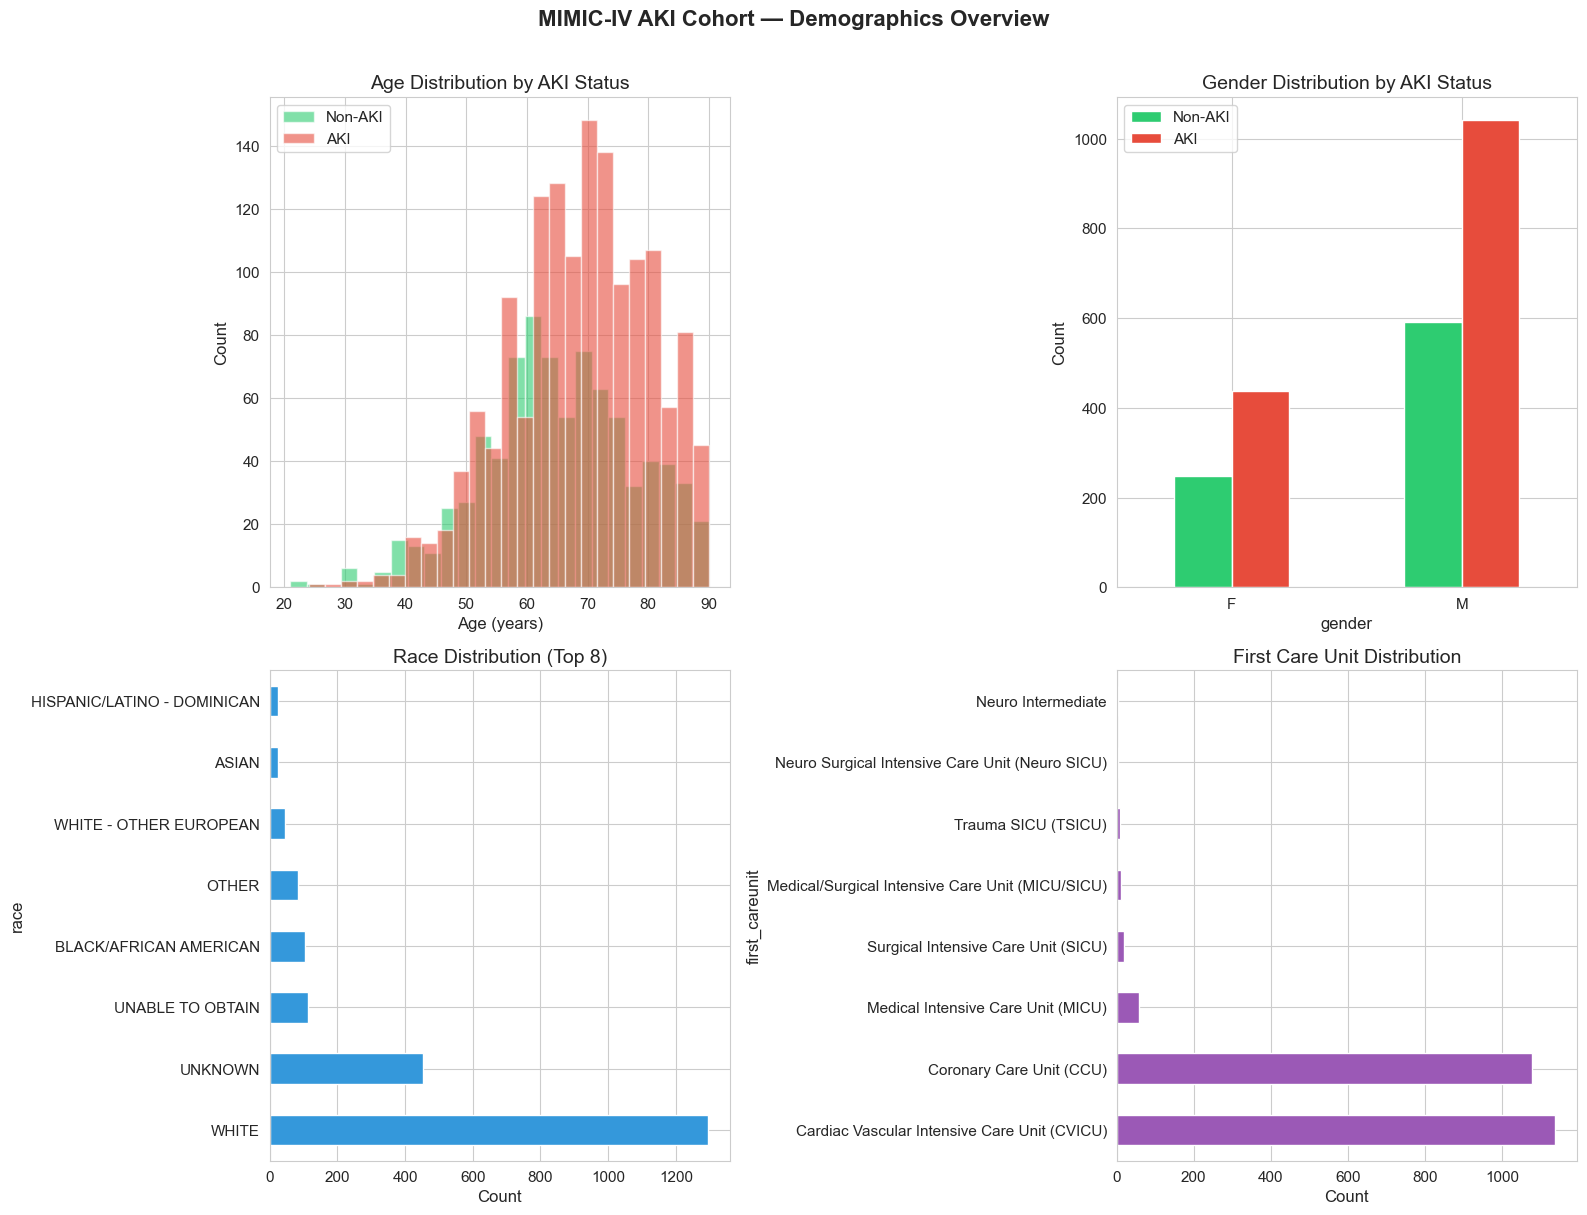

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Age distribution
ax = axes[0, 0]
for label, color, name in [(0, '#2ecc71', 'Non-AKI'), (1, '#e74c3c', 'AKI')]:
    subset = df.loc[df['aki_label'] == label, 'admission_age'].dropna()
    ax.hist(subset, bins=25, alpha=0.6, color=color, label=name, edgecolor='white')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.set_title('Age Distribution by AKI Status')
ax.legend()

# Gender
ax = axes[0, 1]
gender_ct = pd.crosstab(df['gender'], df['aki_label'])
gender_ct.columns = ['Non-AKI', 'AKI']
gender_ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='white', rot=0)
ax.set_title('Gender Distribution by AKI Status')
ax.set_ylabel('Count')

# Race
ax = axes[1, 0]
race_counts = df['race'].fillna('Unknown').value_counts().head(8)
race_counts.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_title('Race Distribution (Top 8)')
ax.set_xlabel('Count')

# Care unit
ax = axes[1, 1]
unit_counts = df['first_careunit'].value_counts()
unit_counts.plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='white')
ax.set_title('First Care Unit Distribution')
ax.set_xlabel('Count')

plt.suptitle('MIMIC-IV AKI Cohort — Demographics Overview', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Feature-level Statistics (Checklist Item 9)

> **Continuous variables:** N, Missing, Mean, SD, Min, Q1, Median, Q3, Max, IQR
>
> **Binary variables:** Yes count, No count, Percentage
>
> **Categorical variables:** Value counts and percentages

In [7]:
valid_continuous = [v for v in continuous_vars if v in df.columns]
desc = df[valid_continuous].describe().T
desc['missing_n'] = df[valid_continuous].isnull().sum().values
desc['missing_pct'] = (df[valid_continuous].isnull().sum() / len(df) * 100).round(2).values
desc['IQR'] = desc['75%'] - desc['25%']
desc = desc[['count', 'missing_n', 'missing_pct', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR']]
desc.columns = ['N', 'Missing(n)', 'Missing(%)', 'Mean', 'SD', 'Min', 'Q1', 'Median', 'Q3', 'Max', 'IQR']

print("=" * 130)
print("FEATURE-LEVEL DESCRIPTIVE STATISTICS — CONTINUOUS VARIABLES")
print("=" * 130)
display(desc.round(3))

FEATURE-LEVEL DESCRIPTIVE STATISTICS — CONTINUOUS VARIABLES


,N,Missing(n),Missing(%),Mean,SD,Min,Q1,Median,Q3,Max,IQR
admission_age,2316.0,0,0.00,67.380,12.024,21.000,59.000,68.000,76.000,90.000,17.000
weight,2257.0,59,2.55,82.936,19.284,1.000,70.000,81.000,94.000,228.900,24.000
height,1672.0,644,27.81,170.694,9.999,122.000,165.000,173.000,178.000,198.000,13.000
heart_rate_max,2314.0,2,0.09,92.549,15.752,50.000,82.000,91.000,101.000,200.000,19.000
sys_bp_min,2314.0,2,0.09,93.656,14.923,23.000,85.000,93.000,102.000,156.000,17.000
mean_bp_min,2314.0,2,0.09,64.115,11.914,2.000,57.000,64.000,71.000,107.000,14.000
dias_bp_min,2314.0,2,0.09,50.545,11.323,11.000,44.000,50.000,57.000,92.000,13.000
resp_rate_max,2310.0,6,0.26,25.132,5.568,14.000,21.000,24.000,28.000,67.000,7.000
temperature_max,2203.0,113,4.88,36.979,0.509,32.000,36.670,36.890,37.170,39.560,0.500
glucose_vitalsign_max,2210.0,106,4.58,183.874,77.554,73.000,134.000,168.000,211.000,1041.000,77.000


In [8]:
print()
print("=" * 100)
print("FEATURE-LEVEL STATISTICS — BINARY / FLAG VARIABLES")
print("=" * 100)
b_rows = []
for var in binary_vars:
    if var not in df.columns:
        continue
    valid = df[var].notna().sum()
    pos = int(df[var].astype(float).sum())
    neg = int(valid - pos)
    pct = pos / valid * 100 if valid > 0 else 0
    miss = int(df[var].isna().sum())
    b_rows.append({'Variable': var, 'Yes (n)': pos, 'No (n)': neg,
                   'Total Valid': int(valid), 'Yes (%)': f'{pct:.1f}', 'Missing (n)': miss})
display(pd.DataFrame(b_rows))


FEATURE-LEVEL STATISTICS — BINARY / FLAG VARIABLES


,Variable,Yes (n),No (n),Total Valid,Yes (%),Missing (n)
0,first_hosp_stay,2234,82,2316,96.5,0
1,is_afib,150,2166,2316,6.5,0
2,is_paced,541,1775,2316,23.4,0
3,is_high_grade_block,11,2305,2316,0.5,0
4,invasive_vent_flag,817,1499,2316,35.3,0
5,non_invasive_vent_flag,21,2295,2316,0.9,0
6,vaso_flag,732,1584,2316,31.6,0
7,gcs_unable_max,986,1316,2302,42.8,14
8,infection_suspected_flag,678,1638,2316,29.3,0
9,blood_culture_flag,118,2198,2316,5.1,0


In [9]:
print()
print("=" * 100)
print("FEATURE-LEVEL STATISTICS — CATEGORICAL VARIABLES")
print("=" * 100)
for var in categorical_vars:
    if var not in df.columns:
        continue
    print(f"\n━━━ {var} ━━━")
    vc = df[var].fillna('(Missing)').value_counts()
    vc_pct = (df[var].fillna('(Missing)').value_counts(normalize=True) * 100).round(2)
    display(pd.DataFrame({'Count': vc, 'Percentage (%)': vc_pct}))


FEATURE-LEVEL STATISTICS — CATEGORICAL VARIABLES

━━━ gender ━━━


,Count,Percentage (%)
gender,,
M,1632,70.47
F,684,29.53



━━━ race ━━━


,Count,Percentage (%)
race,,
WHITE,1294,55.87
UNKNOWN,452,19.52
UNABLE TO OBTAIN,114,4.92
BLACK/AFRICAN AMERICAN,105,4.53
OTHER,85,3.67
WHITE - OTHER EUROPEAN,46,1.99
ASIAN,25,1.08
HISPANIC/LATINO - DOMINICAN,24,1.04
HISPANIC/LATINO - PUERTO RICAN,23,0.99



━━━ first_careunit ━━━


,Count,Percentage (%)
first_careunit,,
Cardiac Vascular Intensive Care Unit (CVICU),1138,49.14
Coronary Care Unit (CCU),1078,46.55
Medical Intensive Care Unit (MICU),57,2.46
Surgical Intensive Care Unit (SICU),18,0.78
Medical/Surgical Intensive Care Unit (MICU/SICU),11,0.47
Trauma SICU (TSICU),9,0.39
Neuro Surgical Intensive Care Unit (Neuro SICU),3,0.13
Neuro Intermediate,2,0.09


### 2.1 Distribution Plots — Key Continuous Variables

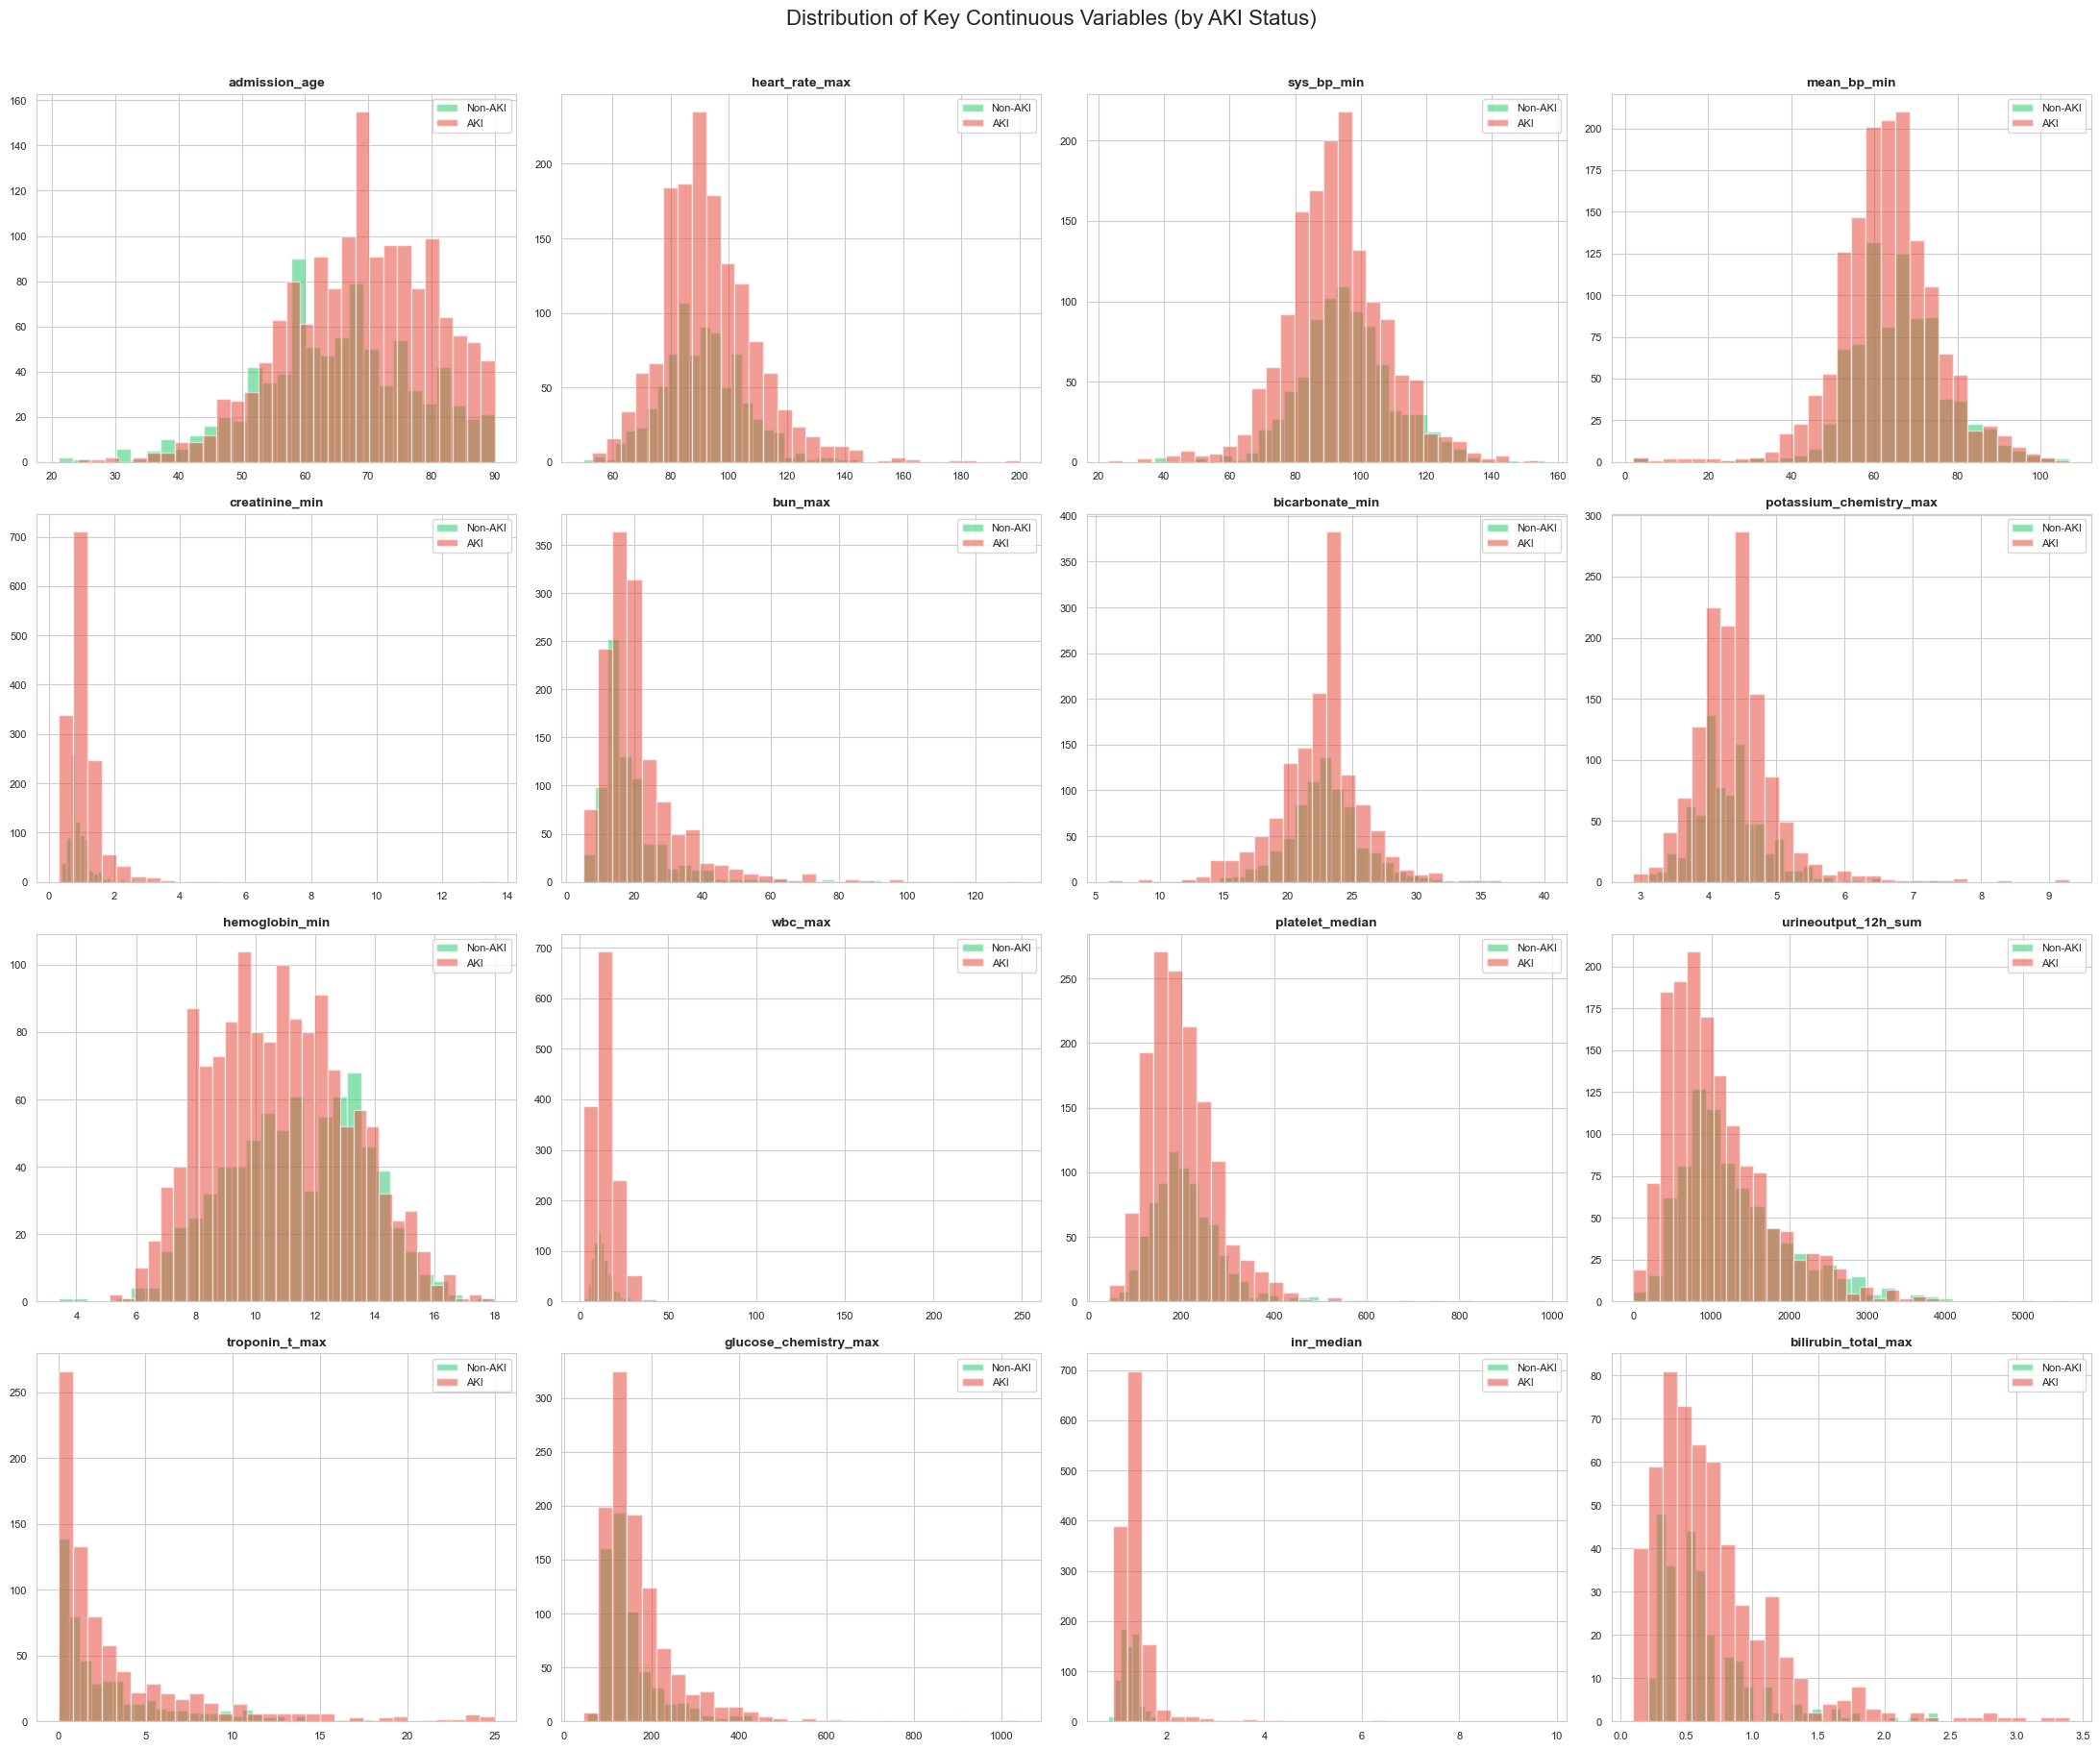

In [10]:
key_vars = [v for v in [
    'admission_age', 'heart_rate_max', 'sys_bp_min', 'mean_bp_min',
    'creatinine_min', 'bun_max', 'bicarbonate_min', 'potassium_chemistry_max',
    'hemoglobin_min', 'wbc_max', 'platelet_median', 'urineoutput_12h_sum',
    'troponin_t_max', 'glucose_chemistry_max', 'inr_median', 'bilirubin_total_max'
] if v in df.columns]

n_cols = 4
n_rows = (len(key_vars) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.5 * n_rows))
axes_flat = axes.flatten()

for i, var in enumerate(key_vars):
    ax = axes_flat[i]
    for label, color, name in [(0, '#2ecc71', 'Non-AKI'), (1, '#e74c3c', 'AKI')]:
        subset = df.loc[df['aki_label'] == label, var].dropna()
        ax.hist(subset, bins=30, alpha=0.55, color=color, label=name, edgecolor='white')
    ax.set_title(var, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

for j in range(len(key_vars), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Distribution of Key Continuous Variables (by AKI Status)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

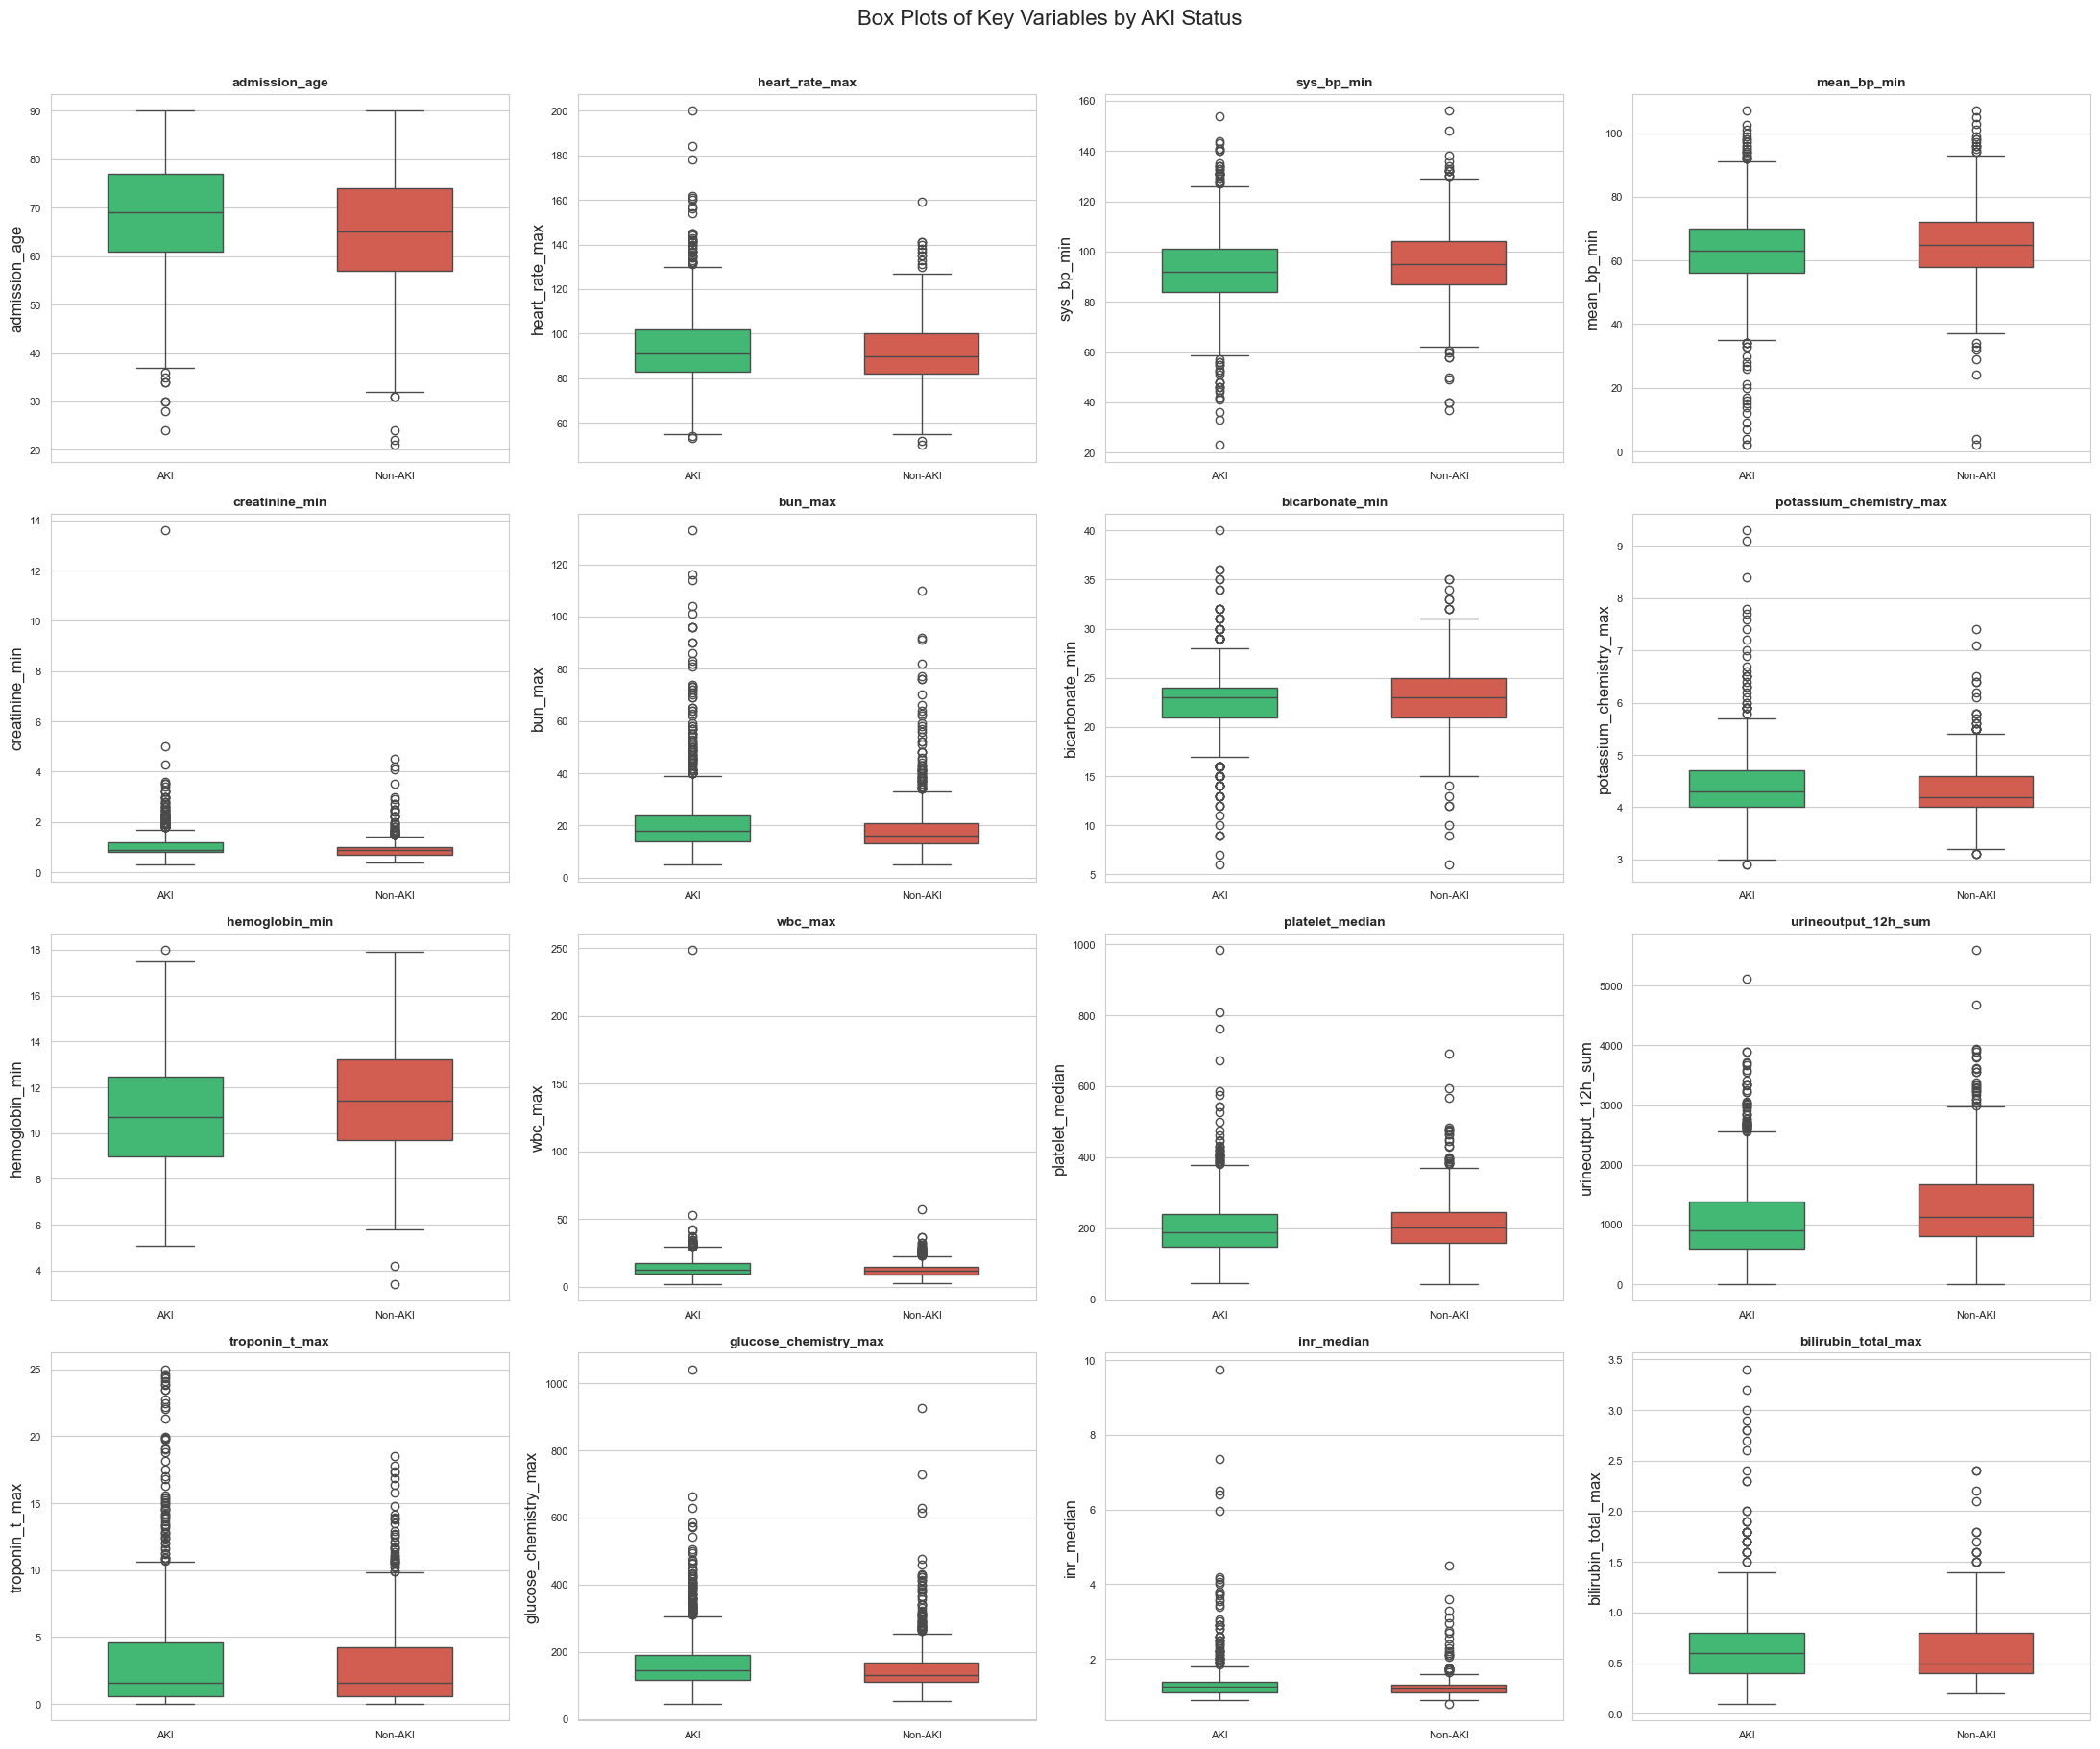

In [11]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.5 * n_rows))
axes_flat = axes.flatten()

for i, var in enumerate(key_vars):
    ax = axes_flat[i]
    tmp = df[['aki_label', var]].dropna().copy()
    tmp['AKI Status'] = tmp['aki_label'].map({0: 'Non-AKI', 1: 'AKI'})
    sns.boxplot(data=tmp, x='AKI Status', y=var, ax=ax,
                palette=['#2ecc71', '#e74c3c'], width=0.5)
    ax.set_title(var, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=8)

for j in range(len(key_vars), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Box Plots of Key Variables by AKI Status', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Data Quality Analysis (Checklist Items 6, 11, 13)

> **Item 6:** Data quality assessment (completeness, plausibility)
>
> **Item 11:** Missing rate per feature
>
> **Item 13:** Class distribution / imbalance

### 3.1 Missing Data Analysis (Item 11)

In [12]:
all_features = [c for c in df.columns if c not in ['subject_id', 'hadm_id', 'stay_id']]
missing = df[all_features].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Feature': missing.index,
    'Missing (n)': missing.values,
    'Missing (%)': missing_pct.values,
    'Available (n)': (len(df) - missing).values,
    'Available (%)': (100 - missing_pct).values
}).sort_values('Missing (%)', ascending=False).reset_index(drop=True)

print("=" * 100)
print("DATA QUALITY — MISSING RATE PER FEATURE")
print("=" * 100)
display(missing_df)

n_complete = int((missing_pct == 0).sum())
n_low = int(((missing_pct > 0) & (missing_pct <= 10)).sum())
n_moderate = int(((missing_pct > 10) & (missing_pct <= 50)).sum())
n_high = int((missing_pct > 50).sum())
print()
print("--- Missing Data Summary ---")
print(f"  Complete features (0% missing):     {n_complete}")
print(f"  Low missing (0–10%):                {n_low}")
print(f"  Moderate missing (10–50%):           {n_moderate}")
print(f"  High missing (>50%):                {n_high}")
print(f"  Total features:                     {len(all_features)}")

DATA QUALITY — MISSING RATE PER FEATURE


,Feature,Missing (n),Missing (%),Available (n),Available (%)
0,ntprobnp_max,2247,97.02,69,2.98
1,bands_max,2244,96.89,72,3.11
2,amylase_median,2215,95.64,101,4.36
3,ld_ldh_max,1828,78.93,488,21.07
4,albumin_median,1822,78.67,494,21.33
5,alp_median,1512,65.28,804,34.72
6,ast_max,1507,65.07,809,34.93
7,bilirubin_total_max,1504,64.94,812,35.06
8,alt_max,1504,64.94,812,35.06
9,fibrinogen_median,1487,64.21,829,35.79



--- Missing Data Summary ---
  Complete features (0% missing):     23
  Low missing (0–10%):                20
  Moderate missing (10–50%):           7
  High missing (>50%):                16
  Total features:                     66


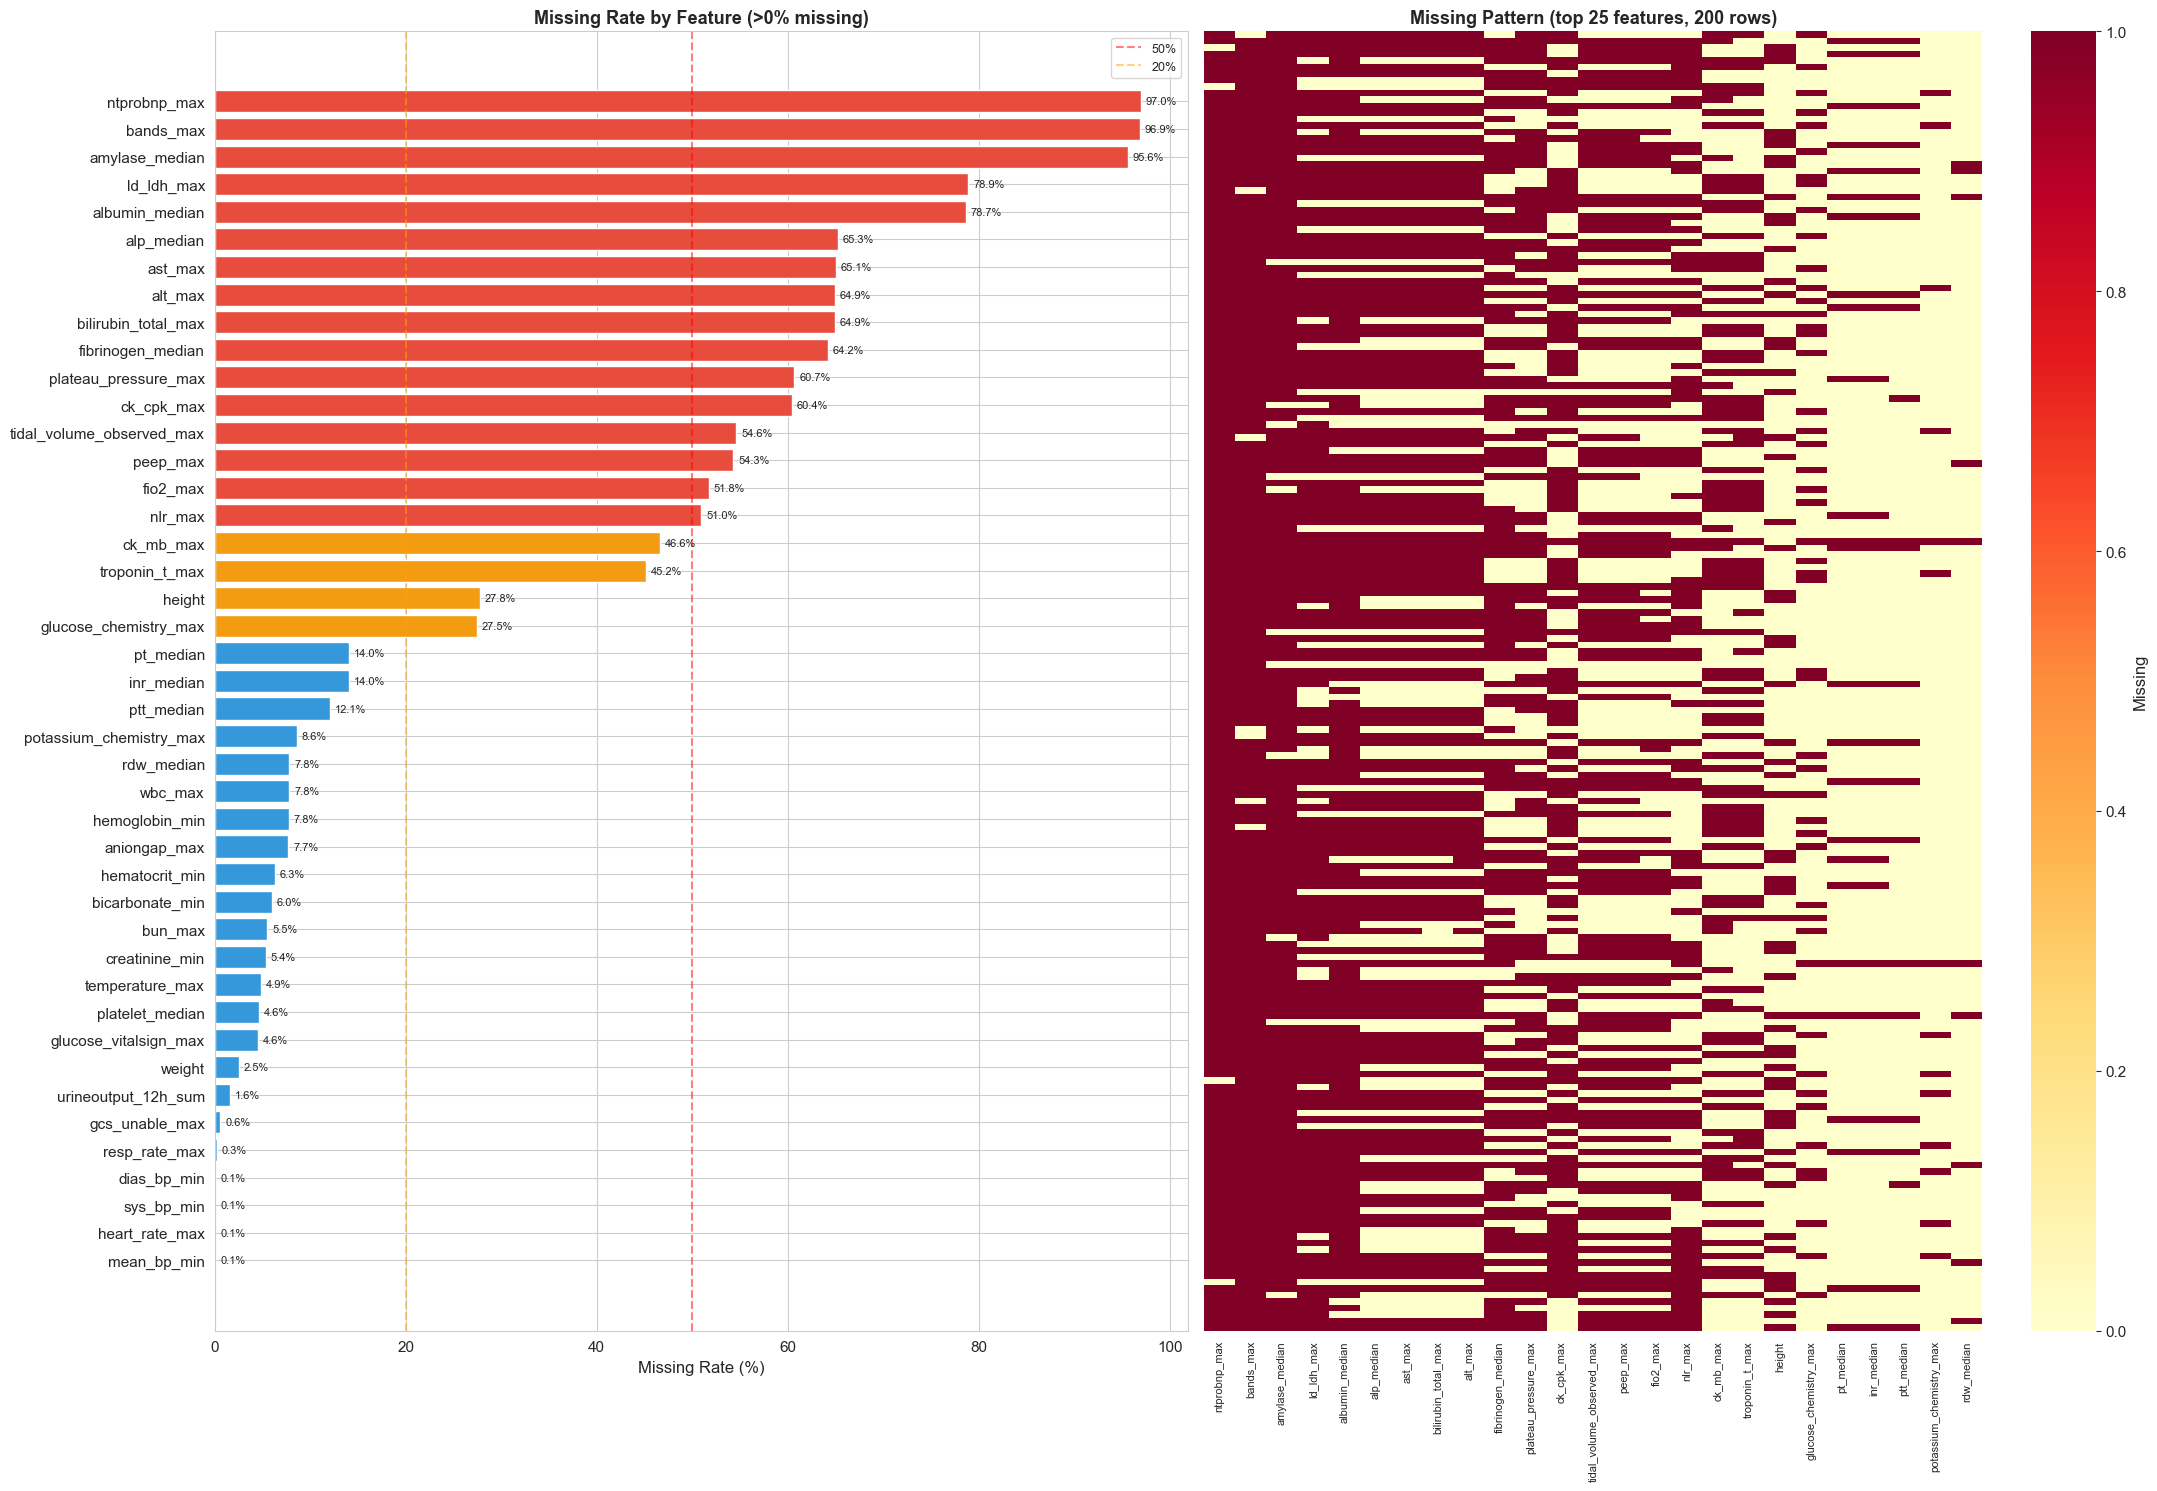

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(22, max(8, len(missing_df[missing_df['Missing (%)'] > 0]) * 0.35)))

# Bar chart
missing_pos = missing_df[missing_df['Missing (%)'] > 0].sort_values('Missing (%)', ascending=True)
if len(missing_pos) > 0:
    ax = axes[0]
    colors = ['#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#3498db' for x in missing_pos['Missing (%)']]
    ax.barh(missing_pos['Feature'], missing_pos['Missing (%)'], color=colors, edgecolor='white')
    ax.set_xlabel('Missing Rate (%)', fontsize=12)
    ax.set_title('Missing Rate by Feature (>0% missing)', fontsize=13, fontweight='bold')
    ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
    ax.axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='20%')
    ax.legend(fontsize=9)
    for idx, val in enumerate(missing_pos['Missing (%)']):
        ax.text(val + 0.5, idx, f'{val:.1f}%', va='center', fontsize=8)
else:
    axes[0].text(0.5, 0.5, 'No missing data!', ha='center', va='center', fontsize=16)

# Heatmap
ax = axes[1]
top_cols = missing_df.head(25)['Feature'].tolist()
if len(top_cols) > 0:
    sample = df[top_cols].sample(min(200, len(df)), random_state=42)
    sns.heatmap(sample.isnull().astype(int), cbar_kws={'label': 'Missing'},
                yticklabels=False, cmap='YlOrRd', ax=ax, linewidths=0)
    ax.set_title('Missing Pattern (top 25 features, 200 rows)', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=90, labelsize=8)

plt.tight_layout()
plt.show()

### 3.2 Class Distribution / Imbalance (Item 13)

CLASS DISTRIBUTION — AKI LABEL (Target Variable)


,Class,Count,Percentage (%)
0,Non-AKI (0),838,36.2
1,AKI (1),1478,63.8


Imbalance ratio (Non-AKI : AKI) = 0.57 : 1


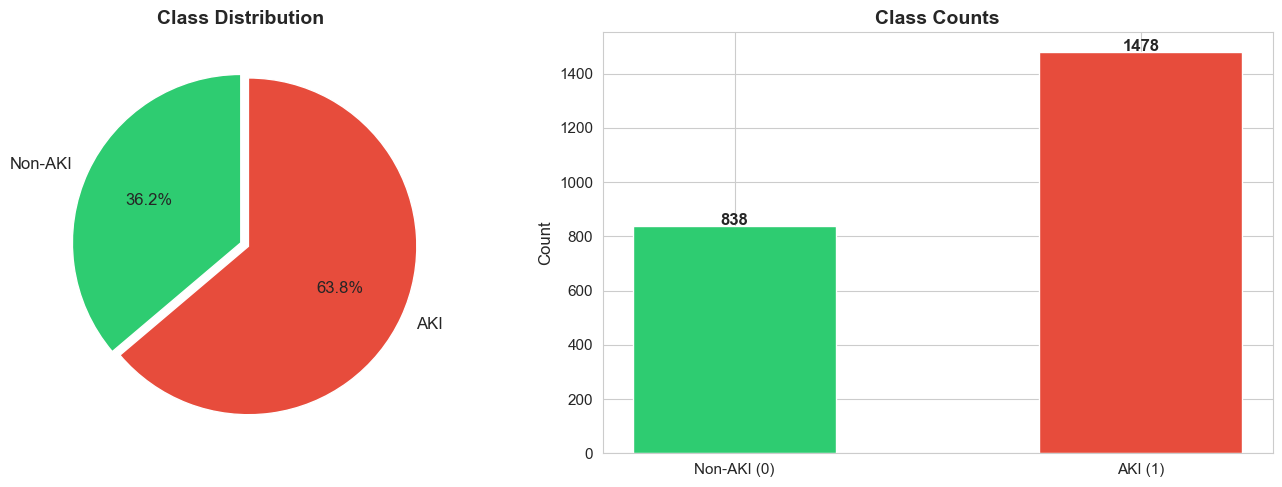

In [14]:
print("=" * 70)
print("CLASS DISTRIBUTION — AKI LABEL (Target Variable)")
print("=" * 70)
cc = df['aki_label'].value_counts().sort_index()
cp = (df['aki_label'].value_counts(normalize=True) * 100).sort_index()
class_df = pd.DataFrame({
    'Class': ['Non-AKI (0)', 'AKI (1)'],
    'Count': [cc.get(0, 0), cc.get(1, 0)],
    'Percentage (%)': [f"{cp.get(0, 0):.1f}", f"{cp.get(1, 0):.1f}"]
})
display(class_df)

ratio = cc.get(0, 1) / cc.get(1, 1) if cc.get(1, 0) > 0 else float('inf')
print(f"Imbalance ratio (Non-AKI : AKI) = {ratio:.2f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie([cc.get(0, 0), cc.get(1, 0)], labels=['Non-AKI', 'AKI'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.05), textprops={'fontsize': 12})
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')

bars = axes[1].bar(['Non-AKI (0)', 'AKI (1)'], [cc.get(0, 0), cc.get(1, 0)],
                    color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Class Counts', fontsize=14, fontweight='bold')
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 5, f'{int(h)}',
                 ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

### 3.3 Feature Correlations

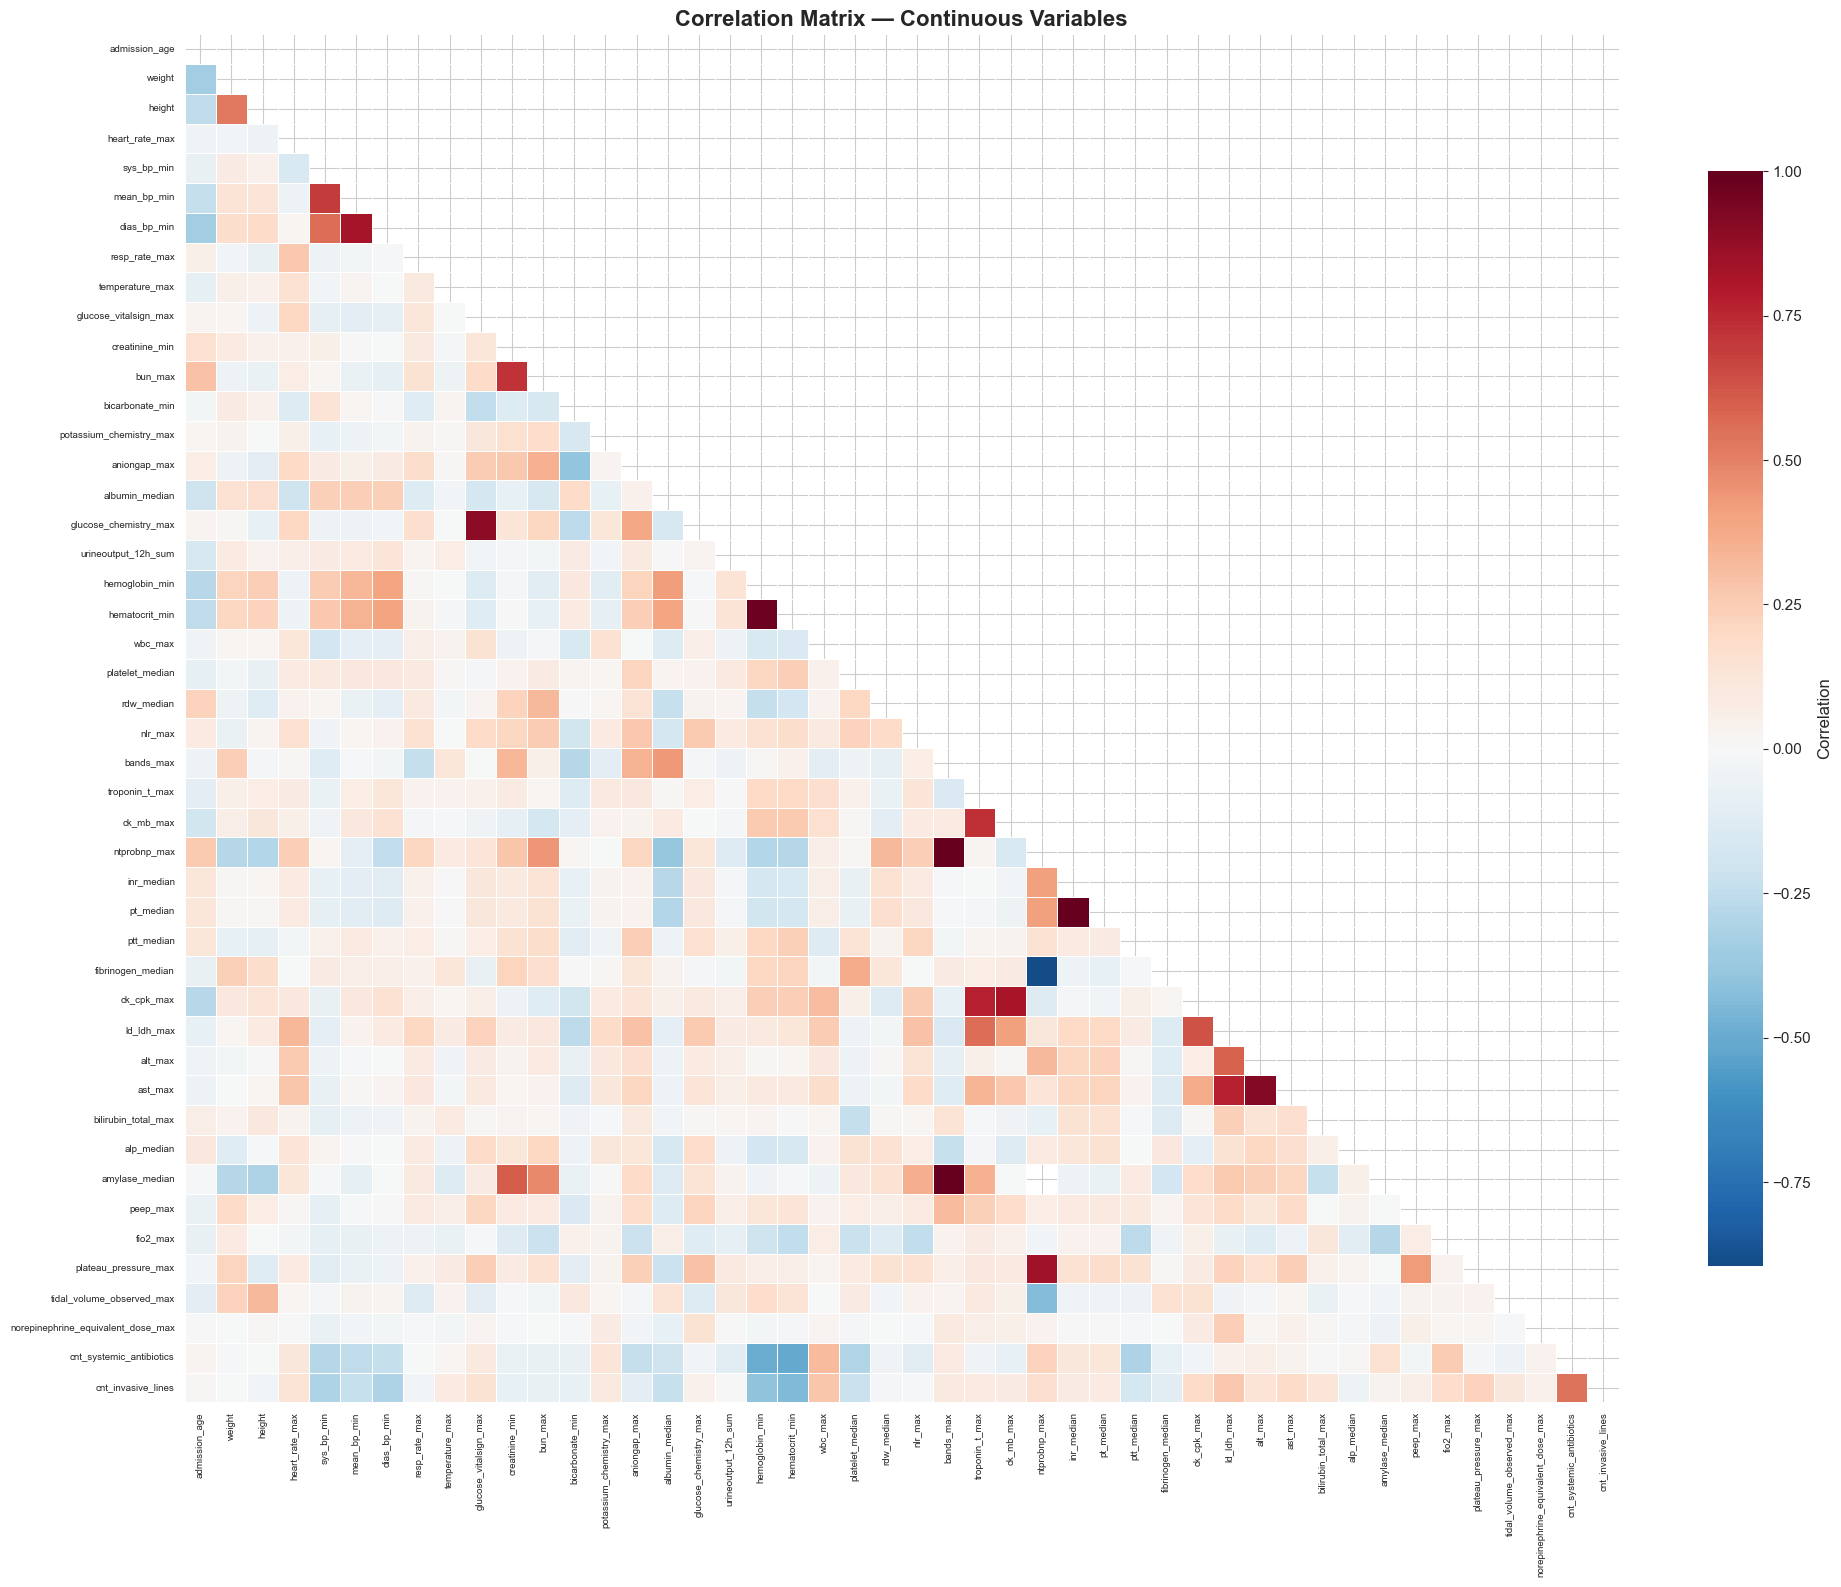

Highly correlated pairs (|r| > 0.7):


,Feature 1,Feature 2,Correlation
5,bands_max,ntprobnp_max,1.000
6,bands_max,amylase_median,1.000
12,inr_median,pt_median,0.985
4,hemoglobin_min,hematocrit_min,0.973
14,alt_max,ast_max,0.913
10,ntprobnp_max,fibrinogen_median,-0.894
2,glucose_vitalsign_max,glucose_chemistry_max,0.893
11,ntprobnp_max,plateau_pressure_max,0.846
1,mean_bp_min,dias_bp_min,0.827
9,ck_mb_max,ck_cpk_max,0.818


In [16]:
numeric_cols = df[valid_continuous].select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 2:
    corr = df[numeric_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(20, 16))
    sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
                annot=False, fmt='.2f', linewidths=0.5,
                xticklabels=True, yticklabels=True, ax=ax,
                cbar_kws={'shrink': 0.8, 'label': 'Correlation'})
    ax.set_title('Correlation Matrix — Continuous Variables', fontsize=16, fontweight='bold')
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)
    plt.tight_layout()
    plt.show()

    # High correlations
    high_corr = []
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            if abs(corr.iloc[i, j]) > 0.7:
                high_corr.append({
                    'Feature 1': corr.columns[i],
                    'Feature 2': corr.columns[j],
                    'Correlation': round(corr.iloc[i, j], 3)
                })
    if high_corr:
        print("Highly correlated pairs (|r| > 0.7):")
        display(pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False))
    else:
        print("No highly correlated pairs found (|r| > 0.7).")

---
## 4. Export Results

In [17]:
table1.to_csv('MIMIC_Table1_baseline.csv', index=False)
print('Exported: MIMIC_Table1_baseline.csv')

desc.to_csv('MIMIC_feature_continuous_stats.csv')
print('Exported: MIMIC_feature_continuous_stats.csv')

missing_df.to_csv('MIMIC_missing_rates.csv', index=False)
print('Exported: MIMIC_missing_rates.csv')

print()
print('All results exported successfully.')

Exported: MIMIC_Table1_baseline.csv
Exported: MIMIC_feature_continuous_stats.csv
Exported: MIMIC_missing_rates.csv

All results exported successfully.


---
## Summary

This notebook has provided:

| Checklist Item | Content | Status |
|---|---|---|
| **Item 7** — Population demographics | Table 1 with age, gender, race, comorbidities, stratified by AKI | ✅ |
| **Item 9** — Feature-level statistics | Mean, SD, Min, Max, IQR for continuous; distribution for categorical | ✅ |
| **Item 6** — Data quality | Completeness assessment, plausibility review | ✅ |
| **Item 11** — Missing rates | Per-feature missing rate with visualization | ✅ |
| **Item 13** — Class distribution | AKI vs Non-AKI imbalance analysis | ✅ |